In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv("Customer-Churn-Records.csv")

In [66]:
df.shape

(10000, 18)

In [67]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [69]:
df["Exited"].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [70]:
df.drop(
    columns=["RowNumber", "CustomerId", "Surname"],
    inplace=True
)

In [71]:
df = df.drop(
    columns=["Complain", "Satisfaction Score"]
)

In [72]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Card Type', 'Point Earned'],
      dtype='object')

In [73]:
categorical_cols = df.select_dtypes(include="object").columns

numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(categorical_cols)
print(numerical_cols)

Index(['Geography', 'Gender', 'Card Type'], dtype='object')
Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Point Earned'],
      dtype='object')


In [74]:
from sklearn.preprocessing import LabelEncoder

object_cols = df.select_dtypes(include='object').columns

le_dict = {}

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Encoding Completed!")
print(df.dtypes)

Encoding Completed!
CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
Card Type            int64
Point Earned         int64
dtype: object


In [75]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

CreditScore: 15 outliers
Age: 359 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 60 outliers
HasCrCard: 0 outliers
IsActiveMember: 0 outliers
EstimatedSalary: 0 outliers
Exited: 2038 outliers
Point Earned: 0 outliers


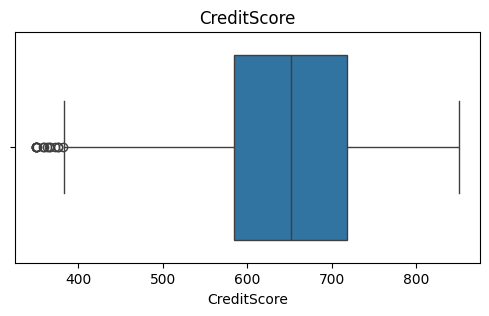

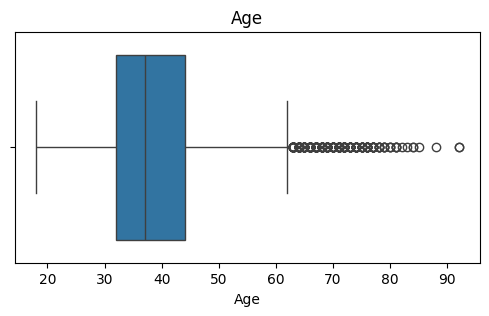

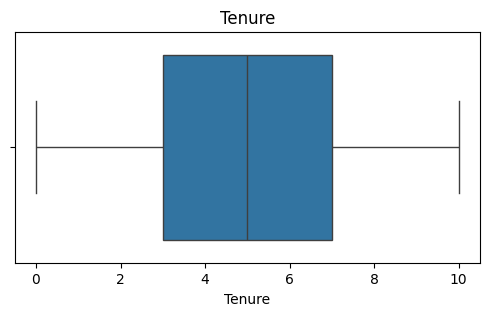

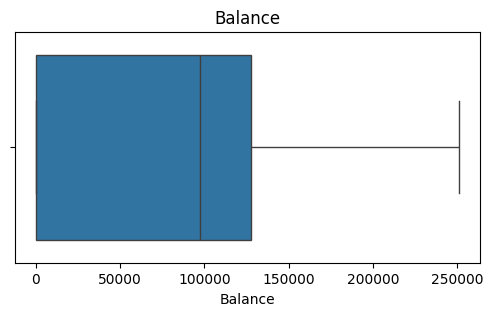

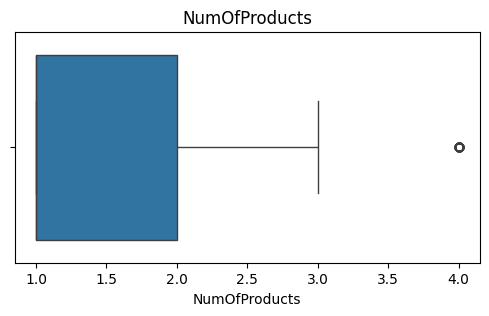

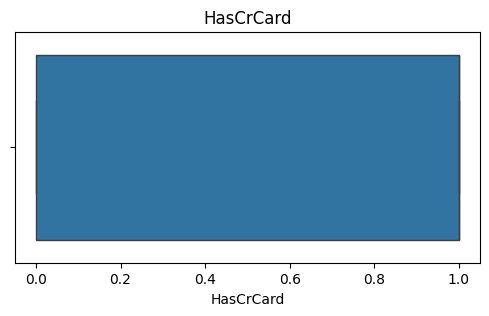

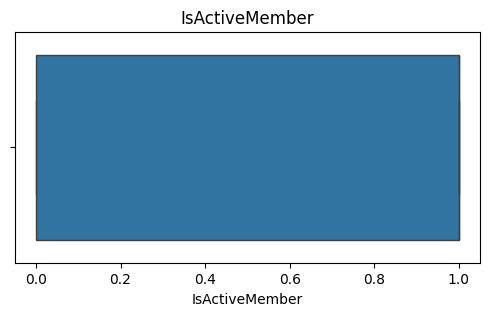

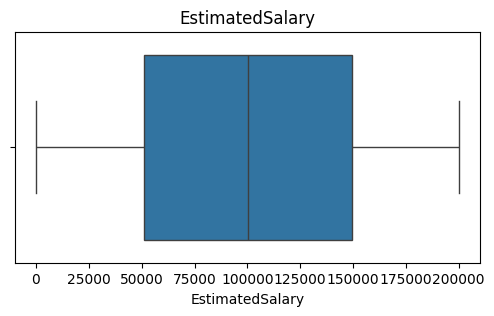

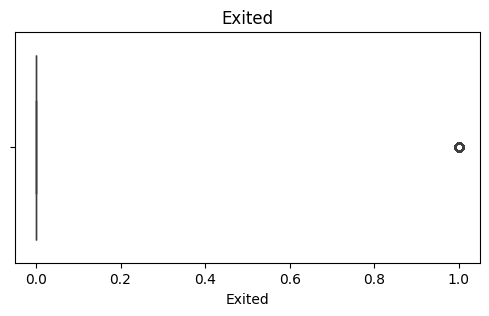

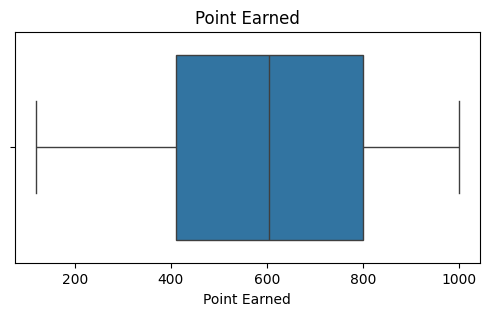

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [77]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 12)
(2000, 12)


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

[[1118  474]
 [ 111  297]]


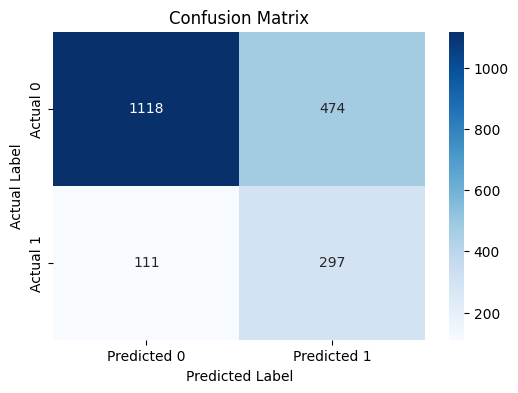

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
print(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report , f1_score

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("f1 score :", f1_score(y_test, lr_pred))

Accuracy : 0.7075
Precision: 0.3852140077821012
Recall   : 0.7279411764705882
f1 score : 0.5038167938931297


In [82]:
print(df.corr()["Exited"].sort_values(ascending=False))

Exited             1.000000
Age                0.285296
Balance            0.118577
Geography          0.035712
EstimatedSalary    0.012490
Point Earned      -0.004628
HasCrCard         -0.006976
Card Type         -0.010861
Tenure            -0.013656
CreditScore       -0.026771
NumOfProducts     -0.047611
Gender            -0.106267
IsActiveMember    -0.156356
Name: Exited, dtype: float64


In [83]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 score :", f1_score(y_test, rf_pred))

Accuracy : 0.864
Precision: 0.7931034482758621
Recall   : 0.45098039215686275
F1 score : 0.575


In [85]:
print(X.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Card Type', 'Point Earned'],
      dtype='object')


In [86]:
for col, encoder in le_dict.items():
    print(f"\n{col}")
    print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))


Geography
{'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}

Gender
{'Female': np.int64(0), 'Male': np.int64(1)}

Card Type
{'DIAMOND': np.int64(0), 'GOLD': np.int64(1), 'PLATINUM': np.int64(2), 'SILVER': np.int64(3)}


In [87]:
new_customer = pd.DataFrame({
    "CreditScore": [650],
    "Geography": [1],        # Use your encoded value
    "Gender": [0],           # Use your encoded value
    "Age": [42],
    "Tenure": [5],
    "Balance": [75000],
    "NumOfProducts": [2],
    "HasCrCard": [1],
    "IsActiveMember": [1],
    "EstimatedSalary": [85000],
    "Card Type": [2],        # Use your encoded value
    "Point Earned": [500]
})

In [88]:
new_customer = new_customer[X.columns]

In [89]:
new_customer_scaled = scaler.transform(new_customer)


In [90]:
if prediction[0] == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is likely to stay.")

Customer is likely to stay.


In [91]:
import joblib

joblib.dump(lr, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le_dict, "label_encoders.pkl")

['label_encoders.pkl']

In [92]:
import joblib

loaded_model = joblib.load("churn_model.pkl")

scaler = joblib.load("scaler.pkl")

le_dict = joblib.load("label_encoders.pkl")

In [93]:
new_customer_scaled = scaler.transform(new_customer)

prediction = loaded_model.predict(new_customer_scaled)